<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype
---  ------             --------------   -----
 0   Index              100000 non-null  int64
 1   Customer Id        100000 non-null  str  
 2   First Name         100000 non-null  str  
 3   Last Name          100000 non-null  str  
 4   Company            100000 non-null  str  
 5   City               100000 non-null  str  
 6   Country            100000 non-null  str  
 7   Phone 1            100000 non-null  str  
 8   Phone 2            100000 non-null  str  
 9   Email              100000 non-null  str  
 10  Subscription Date  100000 non-null  str  
 11  Website            100000 non-null  str  
dtypes: int64(1), str(11)
memory usage: 9.2 MB
None
               Index
count  100000.000000
mean    50000.500000
std     28867.657797
min         1.000000
25%     25000.750000
50%     50000.500000
75%     75000.250000
max    100000.000000
In

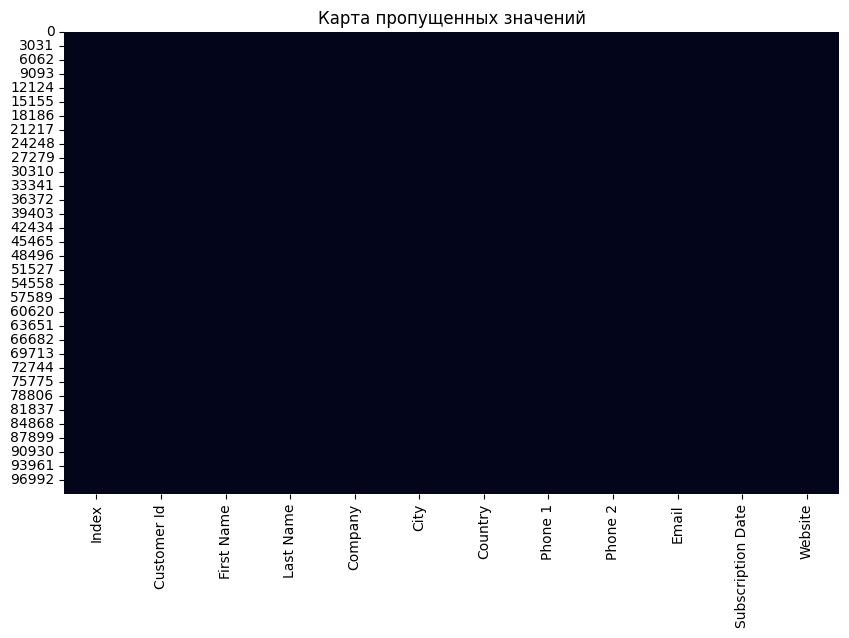

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer


# Загружаем данные
df = pd.read_csv("./Customer Data.csv")

# Базовый анализ
print(df.info())
print(df.describe())

# Проверка пропущенных значений
print(df.isna().sum())

# Визуализация пропуском
plt.figure(figsize=(10, 6))
sns.heatmap(df.isna(), cbar=False)
plt.title("Карта пропущенных значений")
plt.show()

In [4]:
# Проверка количество дупликатов 
duplicated = df.duplicated().sum()
print(f"Найдено {duplicated} количество дупликатов")

# Удаление дупликатов
df = df.drop_duplicates()

# Проверка на частичные дупликаты
partial_dupes = df[df.duplicated(subset=["Customer Id"], keep=False)]
print(f"Найдено {len(partial_dupes)} записей с повторяющимися ID")

if not partial_dupes.empty:
    print(partial_dupes.sort_values('Customer Id'))

df = df.sort_values('Subscription Date').drop_duplicates(subset=["Customer Id"], keep="last")

Найдено 0 количество дупликатов
Найдено 0 записей с повторяющимися ID
